In [15]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
import sys

sys.executable
sys.version

'3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]'

In [2]:
df = pd.read_csv('../data/raw/instagram_usage_lifestyle.csv')
type (df)
pd.core.frame.DataFrame

pandas.core.frame.DataFrame

In [3]:
df_work = df.copy()

# Drop columns that are not needed at this stage
drop_cols = [
    "user_id",
    "app_name",
    # "income_level",
    "age",
    "gender",
    "country",
    "urban_rural",
    "employment_status",
    "education_level",
    "relationship_status",
    "has_children",
    "diet_quality",
    "smoking",
    "alcohol_frequency",
    "last_login_date",
]

df_work.drop(columns=drop_cols, inplace=True, errors="ignore")

# Check
df_work.shape


(1547896, 44)

In [4]:
df_work.isna().sum()
df_work.duplicated().sum()
df_work.describe(percentiles=[.01, .5, .99])

,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,weekly_work_hours,hobbies_count,...,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count,notification_response_rate,account_creation_year,average_session_length_minutes,linked_accounts_count,user_engagement_score
count,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,...,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06
mean,7.143480e+00,6.999384e+00,1.998774e+01,5.499804e+00,2.500084e+01,1.244917e+02,7.950007e+01,8.000105e+03,4.000145e+01,2.996140e+00,...,3.762037e+01,3.295203e+01,5.647662e+01,2.160543e+03,2.604942e+03,5.002404e-01,2.017501e+03,2.050971e+01,1.975254e+00,1.644642e+00
std,3.994556e+00,1.097098e+00,1.183258e+01,2.871232e+00,3.976188e+00,2.020699e+01,1.154874e+01,8.939761e+01,9.997320e+00,1.730508e+00,...,2.535788e+01,2.144569e+01,3.534782e+01,3.402016e+03,2.751922e+03,2.887827e-01,4.611735e+00,8.697454e+00,1.352058e+00,1.812684e+00
min,0.000000e+00,3.000000e+00,0.000000e+00,1.000000e+00,1.500000e+01,9.000000e+01,6.000000e+01,7.566000e+03,0.000000e+00,0.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+01,2.000000e+01,0.000000e+00,2.010000e+03,5.000000e+00,0.000000e+00,6.700000e-01
1%,7.000000e-01,4.400000e+00,0.000000e+00,1.000000e+00,1.570000e+01,9.000000e+01,6.000000e+01,7.793000e+03,1.680000e+01,0.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,8.600000e+01,8.600000e+01,1.000000e-02,2.010000e+03,5.000000e+00,0.000000e+00,8.500000e-01
50%,6.600000e+00,7.000000e+00,2.000000e+01,5.000000e+00,2.500000e+01,1.240000e+02,7.900000e+01,8.000000e+03,4.000000e+01,3.000000e+00,...,3.400000e+01,3.100000e+01,5.400000e+01,1.154000e+03,1.519000e+03,5.000000e-01,2.017000e+03,2.040000e+01,2.000000e+00,1.100000e+00
99%,1.770000e+01,9.600000e+00,4.000000e+01,1.000000e+01,3.430000e+01,1.590000e+02,9.900000e+01,8.209000e+03,6.320000e+01,8.000000e+00,...,1.060000e+02,8.900000e+01,1.450000e+02,1.565000e+04,1.000000e+04,9.900000e-01,2.025000e+03,3.770000e+01,5.000000e+00,1.000000e+01
max,2.410000e+01,1.000000e+01,4.000000e+01,1.000000e+01,4.500000e+01,1.590000e+02,9.900000e+01,8.473000e+03,8.000000e+01,1.000000e+01,...,1.710000e+02,1.380000e+02,2.220000e+02,2.088110e+05,1.000000e+04,1.000000e+00,2.025000e+03,5.200000e+01,5.000000e+00,1.867000e+01


In [5]:
df_work = df_work.sample(
    n=10000,
    random_state=42
).reset_index(drop=True)


In [6]:
df_work["creator_post_ratio"] = (
    df_work["posts_created_per_week"] / (df_work["sessions_per_day"] + 1)
)

df_work["broadcast_ratio"] = (
    df_work["posts_created_per_week"] /
    (df_work["stories_viewed_per_day"] + df_work["reels_watched_per_day"] + 1)
)

df_work["audience_ratio"] = (
    df_work["followers_count"] / (df_work["following_count"] + 1)
)

df_work.shape

(10000, 47)

In [7]:
Activity_cols = [
    "user_engagement_score",
    "sessions_per_day",
    "daily_active_minutes_instagram",
    "average_session_length_minutes",
    "likes_given_per_day",
    "comments_written_per_day",
    "stories_viewed_per_day",
    "reels_watched_per_day",
    "time_on_feed_per_day",
    "time_on_reels_per_day",
]

Creator_cols = [
    "creator_post_ratio",
    "broadcast_ratio",
    "audience_ratio",
]

XY = df_work[Activity_cols + Creator_cols]
XY.shape


(10000, 13)

In [8]:
scaler = StandardScaler()
XY_scaled = scaler.fit_transform(XY)

pca_full = PCA().fit(XY_scaled)
pca_full.explained_variance_ratio_.cumsum()

array([0.58475701, 0.72138856, 0.82966161, 0.90656648, 0.94231848,
       0.95984566, 0.96926291, 0.97821838, 0.98562465, 0.99122826,
       0.99586843, 0.99919232, 1.        ])

In [ ]:
pca = PCA(n_components=2, random_state=42)
XY_pca = pca.fit_transform(XY_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    index = Activity_cols + Creator_cols,
    columns=["PCA1", "PCA2"]
)

loadings.sort_values("PCA1", ascending=False)

,PCA1,PCA2
daily_active_minutes_instagram,0.356660,0.091904
likes_given_per_day,0.350930,0.093270
time_on_feed_per_day,0.349829,0.092380
stories_viewed_per_day,0.347995,0.060745
comments_written_per_day,0.340914,0.092680
time_on_reels_per_day,0.338624,0.092663
reels_watched_per_day,0.318414,0.167258
sessions_per_day,0.280197,0.052674
average_session_length_minutes,0.069555,-0.073124
audience_ratio,-0.001342,0.018419


In [10]:
kmeans = KMeans(
    n_clusters=6,
    n_init=20,
    random_state=42
)

labels = kmeans.fit_predict(XY_pca)

sil = silhouette_score(XY_pca, labels)
sil

0.3695812680276881

In [17]:
cal = calinski_harabasz_score(XY_pca, labels)
cal

13121.354552484776

In [18]:
dav = davies_bouldin_score(XY_pca, labels)
dav

0.8460745146462857

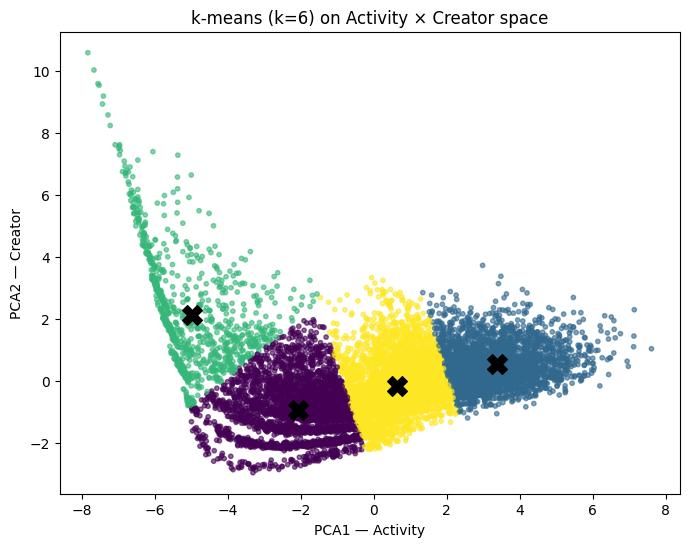

In [ ]:
kmeans6 = KMeans(
    n_clusters=6,
    n_init=20,
    random_state=42
)

labels6 = kmeans6.fit_predict(XY_pca)

plt.figure(figsize=(8, 6))
plt.scatter(
    XY_pca[:, 0],
    XY_pca[:, 1],
    c=labels6,
    s=10,
    alpha=0.6
)

centers = kmeans6.cluster_centers_
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="black",
    s=200,
    marker="X"
)

plt.xlabel("PCA1 — Activity")
plt.ylabel("PCA2 — Creator")
plt.title("k-means (k=6) on Activity × Creator space")
plt.show()

In [12]:
df_seg6 = df_work.copy()
df_seg6["cluster"] = labels6

df_seg6.groupby("cluster")[[
    "posts_created_per_week",
    "creator_post_ratio",
    "broadcast_ratio",
    "sessions_per_day",
    "daily_active_minutes_instagram"
]].mean()

,posts_created_per_week,creator_post_ratio,broadcast_ratio,sessions_per_day,daily_active_minutes_instagram
cluster,,,,,
0,3.133086,0.600068,0.017676,4.569989,84.334040
1,8.603735,0.483182,0.020436,19.748107,344.544170
2,6.410180,3.002196,0.061955,1.122754,12.610778
3,8.815685,0.734106,0.025536,12.913217,243.731290
4,3.761441,0.432513,0.014433,9.019068,164.771610
5,4.539374,1.470772,0.033716,2.003236,35.185545


In [13]:
# df_seg6["income_level"] = df.loc[df_seg6.index, "income_level"]

income_share = (
    df_seg6
    .groupby("cluster")["income_level"]
    .value_counts(normalize=True)
    .unstack()
)

income_order = ["Low", "Lower-middle", "Middle", "Upper-middle", "High"]
income_share = income_share[income_order]
income_share


income_level,Low,Lower-middle,Middle,Upper-middle,High
cluster,,,,,
0,0.190880,0.230647,0.319194,0.150053,0.109226
1,0.205957,0.256941,0.290257,0.143362,0.103483
2,0.209581,0.257485,0.278443,0.152695,0.101796
3,0.200637,0.240446,0.312102,0.143710,0.103105
4,0.205932,0.255508,0.298729,0.147458,0.092373
5,0.185545,0.256742,0.293420,0.165049,0.099245
